In [17]:
# ==========================================
# CHAPTER 1: NOTEBOOK THEME & SETUP
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [18]:
# ==========================================
# CHAPTER 2: PROBLEM STATEMENT
# ==========================================
print("Chapter 2: Predicting if a student passes or fails based on exam scores and demographics.")

Chapter 2: Predicting if a student passes or fails based on exam scores and demographics.


In [19]:
# ==========================================
# CHAPTER 3: DATASET OVERVIEW
# ==========================================
print("Chapter 3: Using the Students Performance Dataset.")

Chapter 3: Using the Students Performance Dataset.


In [20]:
# ==========================================
# CHAPTER 4: DATA UNDERSTANDING
# ==========================================
df = pd.read_csv("StudentsPerformance.csv")

print("--- Shape of Data ---")
print(df.shape)

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Last 5 Rows ---")
print(df.tail())

print("\n--- Random 5 Sample Rows ---")
print(df.sample(5))

print("\n--- Columns List ---")
print(df.columns)

print("\n--- Data Types and Info ---")
df.info()

print("\n--- Summary Statistics ---")
print(df.describe())

--- Shape of Data ---
(1000, 8)

--- First 5 Rows ---
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

--- Last 5 Rows ---
     gender race/ethnicity parental level of education         lunch  \
995  female 

In [21]:
# ==========================================
# CHAPTER 5: DATA CLEANING
# ==========================================
print("\n--- Data Cleaning ---")
print("Missing values count:")
print(df.isnull().sum())
print("Duplicate rows count:", df.duplicated().sum())


--- Data Cleaning ---
Missing values count:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
Duplicate rows count: 0



--- Generating Plots ---


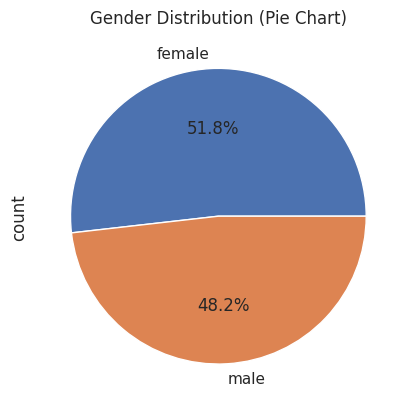

In [22]:
# ==========================================
# CHAPTER 6: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("\n--- Generating Plots ---")

# 1. Pie Chart for Gender Distribution
plt.figure()
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution (Pie Chart)")
plt.show()

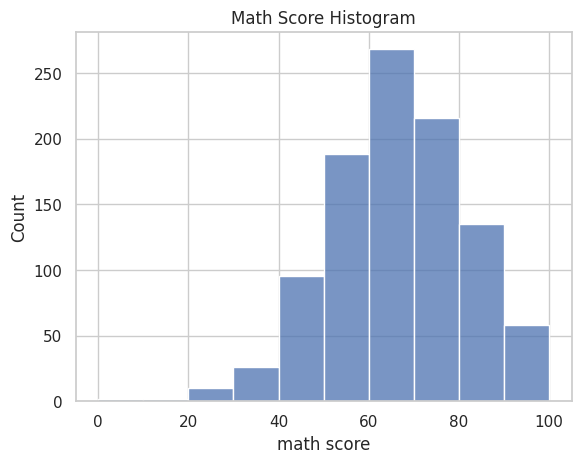

In [23]:
# 2. Histogram of Math Scores
plt.figure()
sns.histplot(df['math score'], bins=10)
plt.title("Math Score Histogram")
plt.show()

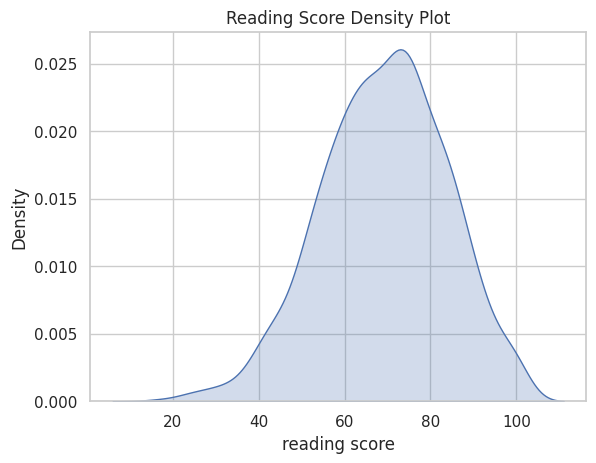

In [24]:
# 3. KDE Plot of Reading Scores
plt.figure()
sns.kdeplot(df['reading score'], fill=True)
plt.title("Reading Score Density Plot")
plt.show()

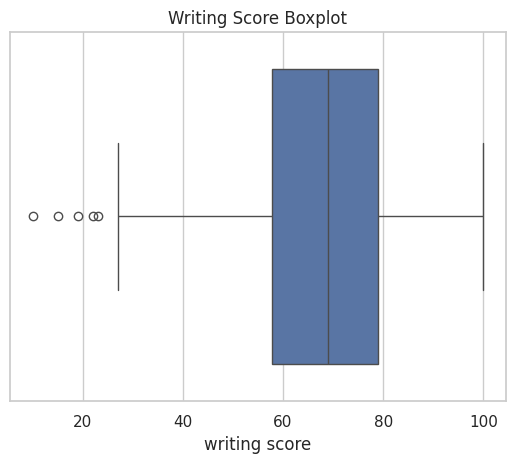

In [25]:
# 4. Boxplot of Writing Scores
plt.figure()
sns.boxplot(x=df['writing score'])
plt.title("Writing Score Boxplot")
plt.show()

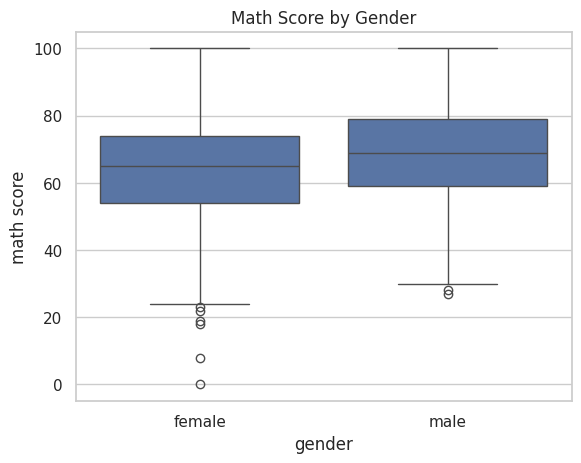

In [26]:
# 5. Boxplot: Math vs Gender
plt.figure()
sns.boxplot(data=df, x='gender', y='math score')
plt.title("Math Score by Gender")
plt.show()

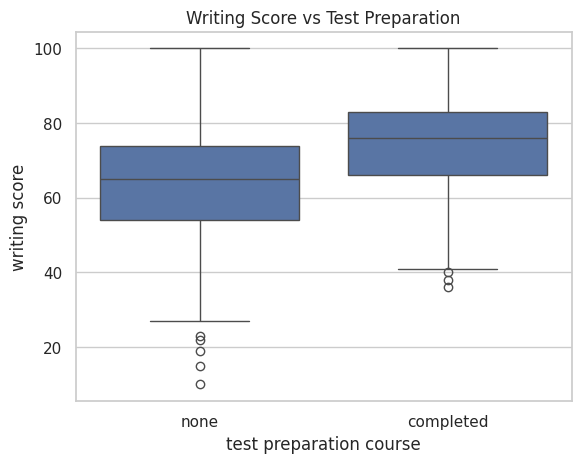

In [27]:
# 6. Boxplot: Writing vs Test Preparation
plt.figure()
sns.boxplot(data=df, x='test preparation course', y='writing score')
plt.title("Writing Score vs Test Preparation")
plt.show()

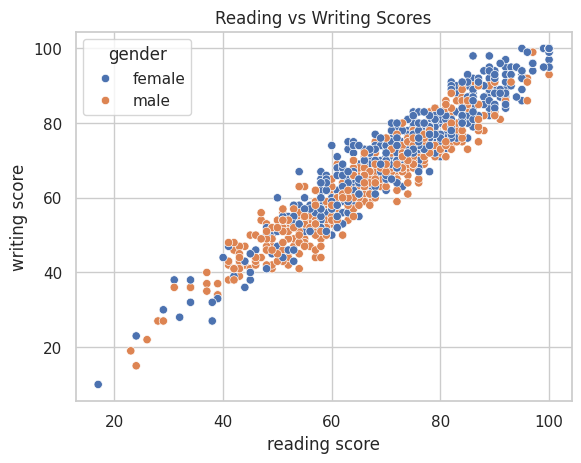

In [28]:
# 7. Scatter Plot: Reading vs Writing
plt.figure()
sns.scatterplot(data=df, x='reading score', y='writing score', hue='gender')
plt.title("Reading vs Writing Scores")
plt.show()

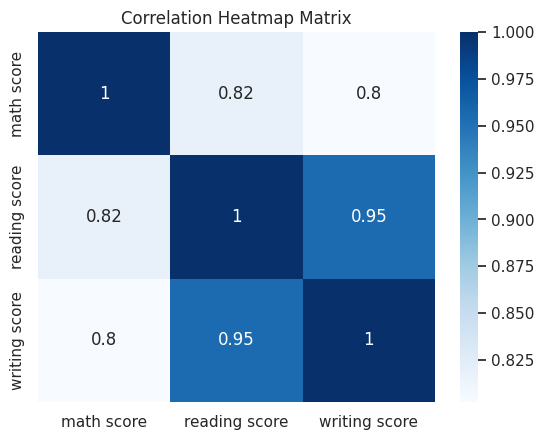

In [29]:
# 8. Correlation Heatmap Matrix
plt.figure()
sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap Matrix")
plt.show()

In [30]:
# ==========================================
# CHAPTER 7: DATA PREPROCESSING
# ==========================================
# Create target: Pass/Fail based on average score >= 60
df['average_score'] = df[['math score','reading score','writing score']].mean(axis=1)
df['Pass'] = np.where(df['average_score'] >= 60, 1, 0)

# Encode categorical variables
categorical_cols = ['gender','race/ethnicity','parental level of education','lunch','test preparation course']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=['Pass','average_score'])
y = df['Pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# ==========================================
# CHAPTER 8 & 9: ML MODELS & EVALUATION
# ==========================================
print("\n--- Training and Evaluating Models ---")

log_reg = LogisticRegression()
dec_tree = DecisionTreeClassifier()
rand_forest = RandomForestClassifier()

log_reg.fit(X_train_scaled, y_train)
dec_tree.fit(X_train, y_train)
rand_forest.fit(X_train, y_train)

pred1 = log_reg.predict(X_test_scaled)
pred2 = dec_tree.predict(X_test)
pred3 = rand_forest.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred1))
print("Decision Tree Accuracy:", accuracy_score(y_test, pred2))
print("Random Forest Accuracy:", accuracy_score(y_test, pred3))

print("\nConfusion Matrix (Logistic Regression):\n", confusion_matrix(y_test, pred1))
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test, pred1))


--- Training and Evaluating Models ---
Logistic Regression Accuracy: 0.995
Decision Tree Accuracy: 0.96
Random Forest Accuracy: 0.98

Confusion Matrix (Logistic Regression):
 [[ 61   1]
 [  0 138]]

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        62
           1       0.99      1.00      1.00       138

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



In [32]:
# ==========================================
# CHAPTER 10: CONCLUSION
# ==========================================
print("\nChapter 10: Conclusion")
print("We successfully built models to predict student performance (Pass/Fail).")
print("Random Forest generally performs best, but Logistic Regression provides interpretable results.")


Chapter 10: Conclusion
We successfully built models to predict student performance (Pass/Fail).
Random Forest generally performs best, but Logistic Regression provides interpretable results.
